### Part 1 — Self-Information

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def self_information(p, eps=1e-12):
    """
    Compute self-information in bits.

    I(x) = -log2(p)

    eps prevents log(0).
    """
    p = np.asarray(p)

    p_safe = np.clip(p, eps, 1.0)

    return -np.log2(p_safe)

In [8]:
probabilities = np.array([
    1.0,
    0.5,
    0.25,
    0.1,
    0.01
])

information = self_information(probabilities)

for p, info in zip(probabilities, information):
    print(f"P = {p:>5}  ->  Information = {info:.4f} bits")

P =   1.0  ->  Information = -0.0000 bits
P =   0.5  ->  Information = 1.0000 bits
P =  0.25  ->  Information = 2.0000 bits
P =   0.1  ->  Information = 3.3219 bits
P =  0.01  ->  Information = 6.6439 bits


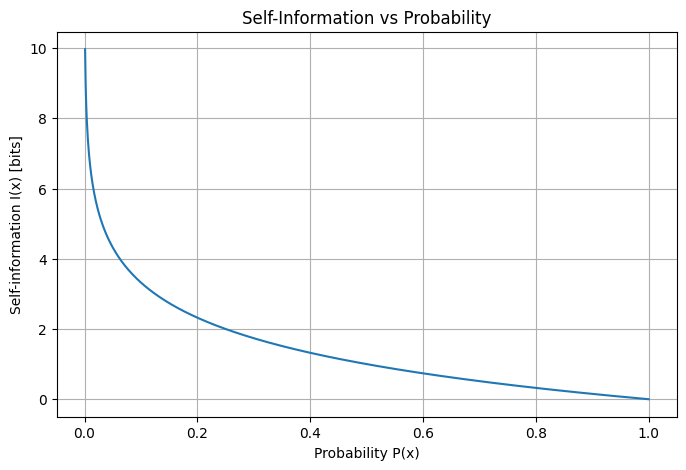

In [9]:
p = np.linspace(0.001, 1.0, 1000)
I = self_information(p)

plt.figure(figsize=(8, 5))

plt.plot(p, I)

plt.xlabel("Probability P(x)")
plt.ylabel("Self-information I(x) [bits]")
plt.title("Self-Information vs Probability")

plt.grid(True)
plt.show()

In [10]:
print(self_information(0.0))

39.86313713864835


In [11]:
predicted_probabilities = np.array([
    0.99,
    0.70,
    0.10,
    0.01
])

losses = self_information(predicted_probabilities)

for p, loss in zip(predicted_probabilities, losses):
    print(f"Probability assigned to correct class: {p:.2f} -> Loss: {loss:.4f} bits")

Probability assigned to correct class: 0.99 -> Loss: 0.0145 bits
Probability assigned to correct class: 0.70 -> Loss: 0.5146 bits
Probability assigned to correct class: 0.10 -> Loss: 3.3219 bits
Probability assigned to correct class: 0.01 -> Loss: 6.6439 bits


### Part 2 — Entropy

In [12]:
def entropy(p, eps=1e-12):
    """
    Compute Shannon entropy in bits.

    H(X) = -sum p(x) log2 p(x)
    """
    p = np.asarray(p, dtype=float)

    # Make sure we have a valid probability distribution
    if not np.isclose(np.sum(p), 1.0):
        raise ValueError("Probabilities must sum to 1.")

    # Avoid log(0)
    p_safe = np.clip(p, eps, 1.0)

    return -np.sum(p * np.log2(p_safe))

In [13]:
p_coin = np.array([0.5, 0.5])

print("Entropy:", entropy(p_coin), "bits")

Entropy: 1.0 bits


In [14]:
p_deterministic = np.array([1.0, 0.0])

print("Entropy:", entropy(p_deterministic), "bits")

Entropy: -0.0 bits


In [15]:
p_uniform = np.array([0.25, 0.25, 0.25, 0.25])

print("Entropy:", entropy(p_uniform), "bits")

Entropy: 2.0 bits


In [16]:
distributions = {
    "Deterministic": np.array([1.0, 0.0, 0.0, 0.0]),
    "Mostly deterministic": np.array([0.90, 0.05, 0.03, 0.02]),
    "Moderately uneven": np.array([0.60, 0.20, 0.10, 0.10]),
    "Uniform": np.array([0.25, 0.25, 0.25, 0.25])
}

for name, p in distributions.items():
    print(f"{name:20s}: {entropy(p):.4f} bits")

Deterministic       : -0.0000 bits
Mostly deterministic: 0.6175 bits
Moderately uneven   : 1.5710 bits
Uniform             : 2.0000 bits


In [17]:
dominant_probs = np.linspace(1.0, 0.25, 100)

entropies = []

for p_main in dominant_probs:
    remaining = 1 - p_main

    p = np.array([
        p_main,
        remaining / 3,
        remaining / 3,
        remaining / 3
    ])

    entropies.append(entropy(p))

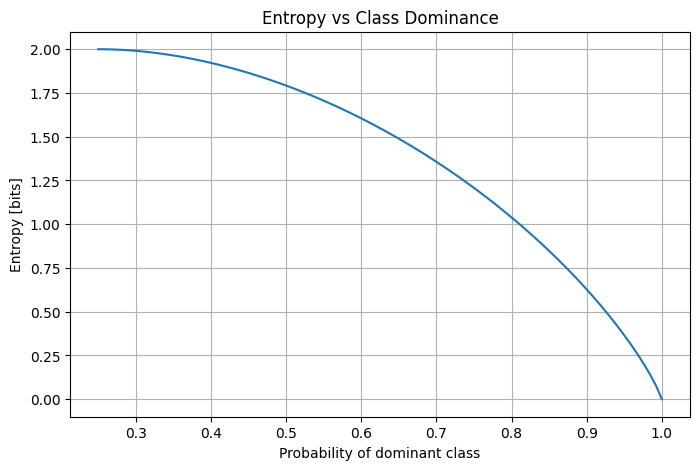

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(dominant_probs, entropies)

plt.xlabel("Probability of dominant class")
plt.ylabel("Entropy [bits]")
plt.title("Entropy vs Class Dominance")

plt.grid(True)
plt.show()

In [19]:
num_classes = np.arange(2, 21)

max_entropies = []

for n in num_classes:
    p = np.ones(n) / n
    max_entropies.append(entropy(p))

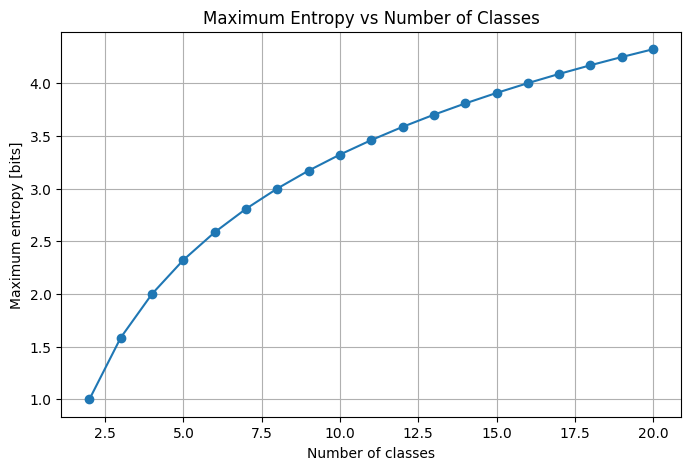

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(num_classes, max_entropies, marker="o")

plt.xlabel("Number of classes")
plt.ylabel("Maximum entropy [bits]")
plt.title("Maximum Entropy vs Number of Classes")

plt.grid(True)
plt.show()

In [21]:
# Deterministic distribution should have zero entropy
assert np.isclose(entropy([1.0, 0.0]), 0.0)

# Fair binary distribution should have 1 bit
assert np.isclose(entropy([0.5, 0.5]), 1.0)

# Uniform distribution over 4 classes should have 2 bits
assert np.isclose(entropy([0.25, 0.25, 0.25, 0.25]), 2.0)

print("All entropy tests passed!")

All entropy tests passed!


### Part 3 — Entropy and Class Imbalance

In [22]:
class_distributions = {
    "50/50": np.array([0.50, 0.50]),
    "60/40": np.array([0.60, 0.40]),
    "70/30": np.array([0.70, 0.30]),
    "80/20": np.array([0.80, 0.20]),
    "90/10": np.array([0.90, 0.10]),
    "99/1":  np.array([0.99, 0.01])
}

for name, p in class_distributions.items():
    print(f"{name}: {entropy(p):.4f} bits")

50/50: 1.0000 bits
60/40: 0.9710 bits
70/30: 0.8813 bits
80/20: 0.7219 bits
90/10: 0.4690 bits
99/1: 0.0808 bits


In [23]:
p_positive = np.linspace(0.001, 0.999, 1000)

binary_entropies = []

for p in p_positive:
    binary_entropies.append(
        entropy([1 - p, p])
    )

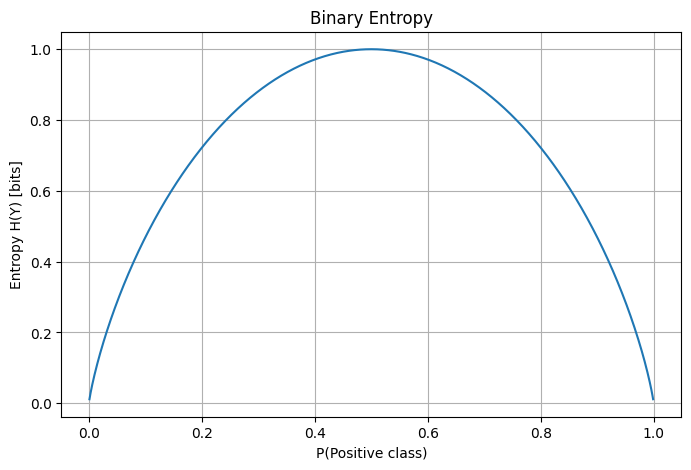

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(p_positive, binary_entropies)

plt.xlabel("P(Positive class)")
plt.ylabel("Entropy H(Y) [bits]")
plt.title("Binary Entropy")

plt.grid(True)
plt.show()

In [25]:
print(entropy([0.2, 0.8]))
print(entropy([0.8, 0.2]))

0.7219280948873623
0.7219280948873623


In [26]:
n_samples = 100_000

y = np.array(
    [0] * 99_900 +
    [1] * 100
)

print("Total samples:", len(y))
print("Class 0:", np.sum(y == 0))
print("Class 1:", np.sum(y == 1))

Total samples: 100000
Class 0: 99900
Class 1: 100


In [27]:
y_pred = np.zeros_like(y)
accuracy = np.mean(y_pred == y)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 99.90%


In [28]:
true_positives = np.sum((y == 1) & (y_pred == 1))
false_negatives = np.sum((y == 1) & (y_pred == 0))

recall = true_positives / (true_positives + false_negatives)

print("Fraud recall:", recall)

Fraud recall: 0.0


In [29]:
class_probs = np.array([
    np.mean(y == 0),
    np.mean(y == 1)
])

print("Class probabilities:", class_probs)
print("Label entropy:", entropy(class_probs), "bits")

Class probabilities: [0.999 0.001]
Label entropy: 0.011407757737461138 bits


In [30]:
imbalance_levels = np.array([
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99,
    0.999
])

imbalance_entropies = [
    entropy([1 - p, p])
    for p in imbalance_levels
]

for p, h in zip(imbalance_levels, imbalance_entropies):
    print(
        f"Positive class = {p:.3f} "
        f"| Negative class = {1-p:.3f} "
        f"| Entropy = {h:.4f} bits"
    )

Positive class = 0.500 | Negative class = 0.500 | Entropy = 1.0000 bits
Positive class = 0.600 | Negative class = 0.400 | Entropy = 0.9710 bits
Positive class = 0.700 | Negative class = 0.300 | Entropy = 0.8813 bits
Positive class = 0.800 | Negative class = 0.200 | Entropy = 0.7219 bits
Positive class = 0.900 | Negative class = 0.100 | Entropy = 0.4690 bits
Positive class = 0.950 | Negative class = 0.050 | Entropy = 0.2864 bits
Positive class = 0.990 | Negative class = 0.010 | Entropy = 0.0808 bits
Positive class = 0.999 | Negative class = 0.001 | Entropy = 0.0114 bits


In [31]:
datasets = {
    "Balanced": [0.5, 0.5],
    "Moderately imbalanced": [0.8, 0.2],
    "Extremely imbalanced": [0.99, 0.01]
}

for name, p in datasets.items():
    h = entropy(p)

    print(
        f"{name:25s} "
        f"Entropy = {h:.4f} bits"
    )

Balanced                  Entropy = 1.0000 bits
Moderately imbalanced     Entropy = 0.7219 bits
Extremely imbalanced      Entropy = 0.0808 bits


### Part 4 — Joint Entropy

In [32]:
joint_uniform = np.array([
    [0.25, 0.25],
    [0.25, 0.25]
])

print(joint_uniform)
print("Total probability:", joint_uniform.sum())

[[0.25 0.25]
 [0.25 0.25]]
Total probability: 1.0


In [33]:
def joint_entropy(joint_p, eps=1e-12):
    """
    Compute joint entropy H(X, Y) in bits.

    joint_p[i, j] = P(X=i, Y=j)
    """
    joint_p = np.asarray(joint_p, dtype=float)

    if not np.isclose(joint_p.sum(), 1.0):
        raise ValueError("Joint probabilities must sum to 1.")

    # Avoid log(0)
    p_safe = np.clip(joint_p, eps, 1.0)

    return -np.sum(joint_p * np.log2(p_safe))

In [34]:
H_XY = joint_entropy(joint_uniform)

print("H(X, Y) =", H_XY, "bits")

H(X, Y) = 2.0 bits


In [35]:
p_x = joint_uniform.sum(axis=1)
p_y = joint_uniform.sum(axis=0)

print("P(X):", p_x)
print("P(Y):", p_y)

P(X): [0.5 0.5]
P(Y): [0.5 0.5]


In [36]:
print("H(X):", entropy(p_x))
print("H(Y):", entropy(p_y))

H(X): 1.0
H(Y): 1.0


In [37]:
joint_dependent = np.array([
    [0.5, 0.0],
    [0.0, 0.5]
])

print(joint_dependent)
print("Total probability:", joint_dependent.sum())

[[0.5 0. ]
 [0.  0.5]]
Total probability: 1.0


In [38]:
print("H(X, Y):", joint_entropy(joint_dependent))

print("Independent:")
print("H(X,Y) =", joint_entropy(joint_uniform))

print("\nPerfectly dependent:")
print("H(X,Y) =", joint_entropy(joint_dependent))


H(X, Y): 1.0
Independent:
H(X,Y) = 2.0

Perfectly dependent:
H(X,Y) = 1.0


In [39]:
joint_partial = np.array([
    [0.45, 0.05],
    [0.05, 0.45]
])

print(joint_partial)
print("Total:", joint_partial.sum())

[[0.45 0.05]
 [0.05 0.45]]
Total: 1.0


In [40]:
print("H(X,Y):", joint_entropy(joint_partial))

H(X,Y): 1.4689955935892813


In [41]:
p_x = joint_partial.sum(axis=1)
p_y = joint_partial.sum(axis=0)

print("P(X):", p_x)
print("P(Y):", p_y)

print("H(X):", entropy(p_x))
print("H(Y):", entropy(p_y))

P(X): [0.5 0.5]
P(Y): [0.5 0.5]
H(X): 1.0
H(Y): 1.0


In [42]:
def conditional_entropy(joint_p):
    """
    Compute H(Y | X) from a joint probability table.

    H(Y | X) = H(X, Y) - H(X)
    """
    joint_p = np.asarray(joint_p, dtype=float)

    p_x = joint_p.sum(axis=1)

    return joint_entropy(joint_p) - entropy(p_x)

In [43]:
print("Independent:")
print("H(Y|X) =", conditional_entropy(joint_uniform))

print("\nPartially dependent:")
print("H(Y|X) =", conditional_entropy(joint_partial))

print("\nPerfectly dependent:")
print("H(Y|X) =", conditional_entropy(joint_dependent))

H_X = entropy(joint_partial.sum(axis=1))
H_XY = joint_entropy(joint_partial)
H_Y_given_X = conditional_entropy(joint_partial)

print("H(X)       =", H_X)
print("H(X,Y)     =", H_XY)
print("H(Y|X)     =", H_Y_given_X)

print("\nH(X) + H(Y|X) =", H_X + H_Y_given_X)

Independent:
H(Y|X) = 1.0

Partially dependent:
H(Y|X) = 0.46899559358928133

Perfectly dependent:
H(Y|X) = 0.0
H(X)       = 1.0
H(X,Y)     = 1.4689955935892813
H(Y|X)     = 0.46899559358928133

H(X) + H(Y|X) = 1.4689955935892813


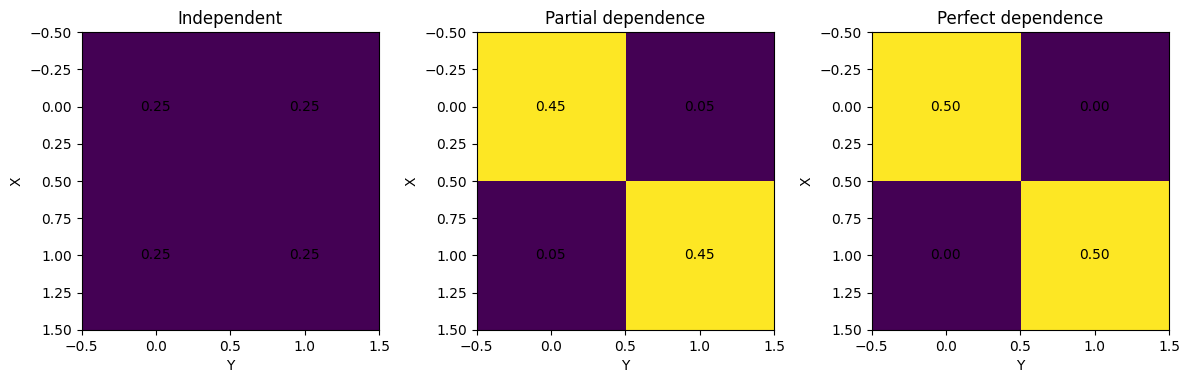

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

joint_distributions = [
    ("Independent", joint_uniform),
    ("Partial dependence", joint_partial),
    ("Perfect dependence", joint_dependent)
]

for ax, (title, joint_p) in zip(axes, joint_distributions):
    ax.imshow(joint_p)

    ax.set_title(title)
    ax.set_xlabel("Y")
    ax.set_ylabel("X")

    for i in range(joint_p.shape[0]):
        for j in range(joint_p.shape[1]):
            ax.text(
                j, i,
                f"{joint_p[i, j]:.2f}",
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

### Part 5 — Mutual Information

In [45]:
def mutual_information(joint_p):
    """
    Compute mutual information I(X; Y) in bits.

    I(X;Y) = H(X) + H(Y) - H(X,Y)
    """
    joint_p = np.asarray(joint_p, dtype=float)

    p_x = joint_p.sum(axis=1)
    p_y = joint_p.sum(axis=0)

    return (
        entropy(p_x)
        + entropy(p_y)
        - joint_entropy(joint_p)
    )

In [46]:
print("Independent:")
print(mutual_information(joint_uniform))

print("\nPartially dependent:")
print(mutual_information(joint_partial))

print("\nPerfectly dependent:")
print(mutual_information(joint_dependent))

Independent:
0.0

Partially dependent:
0.5310044064107187

Perfectly dependent:
1.0


In [47]:
H_Y = entropy(joint_partial.sum(axis=0))
H_Y_given_X = conditional_entropy(joint_partial)

mi_from_conditional = H_Y - H_Y_given_X
mi_direct = mutual_information(joint_partial)

print("H(Y):", H_Y)
print("H(Y|X):", H_Y_given_X)
print("MI from conditional entropy:", mi_from_conditional)
print("MI from joint entropy:", mi_direct)

H(Y): 1.0
H(Y|X): 0.46899559358928133
MI from conditional entropy: 0.5310044064107187
MI from joint entropy: 0.5310044064107187


In [48]:
rng = np.random.default_rng(42)

n = 100_000

X = rng.integers(0, 2, size=n)
Y = rng.integers(0, 2, size=n)

print("First 20 X values:")
print(X[:20])

print("\nFirst 20 Y values:")
print(Y[:20])

First 20 X values:
[0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0]

First 20 Y values:
[1 1 1 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 0 0]


In [49]:
def empirical_joint_distribution(x, y, n_x=None, n_y=None):
    """
    Estimate a joint probability table from discrete samples.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if n_x is None:
        n_x = int(x.max()) + 1

    if n_y is None:
        n_y = int(y.max()) + 1

    joint = np.zeros((n_x, n_y))

    for xi, yi in zip(x, y):
        joint[xi, yi] += 1

    joint /= len(x)

    return joint

In [50]:
joint_independent = empirical_joint_distribution(X, Y)

print(joint_independent)

print(
    "Mutual information:",
    mutual_information(joint_independent),
    "bits"
)

[[0.24694 0.25217]
 [0.2515  0.24939]]
Mutual information: 3.892271628735955e-05 bits


In [51]:
X = rng.integers(0, 2, size=n)

Y = X.copy()

joint_perfect = empirical_joint_distribution(X, Y)

print(joint_perfect)

print(
    "Mutual information:",
    mutual_information(joint_perfect),
    "bits"
)

[[0.50222 0.     ]
 [0.      0.49778]]
Mutual information: 0.9999857795967982 bits


In [52]:
X = rng.integers(0, 2, size=n)

noise_probability = 0.10

noise = rng.random(n) < noise_probability

Y = np.logical_xor(X, noise).astype(int)

joint_noisy = empirical_joint_distribution(X, Y)

print(joint_noisy)

print(
    "Mutual information:",
    mutual_information(joint_noisy),
    "bits"
)

[[0.45024 0.05028]
 [0.04923 0.45025]]
Mutual information: 0.5325659983870765 bits


In [53]:
noise_levels = np.linspace(0, 0.5, 21)

mi_values = []

for noise_probability in noise_levels:

    X = rng.integers(0, 2, size=n)

    noise = rng.random(n) < noise_probability

    Y = np.logical_xor(X, noise).astype(int)

    joint = empirical_joint_distribution(X, Y)

    mi_values.append(mutual_information(joint))

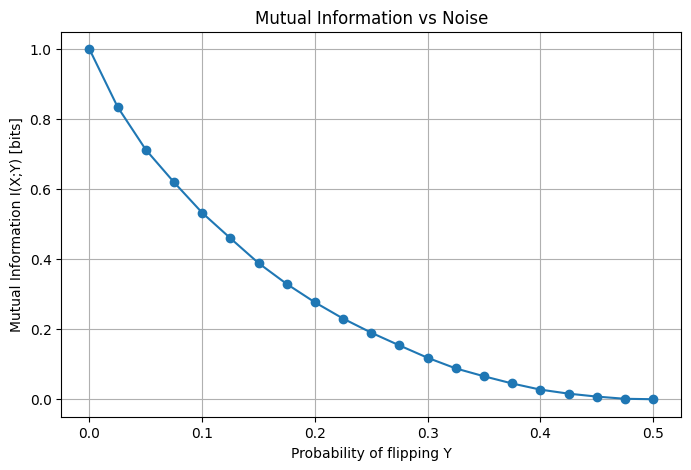

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(noise_levels, mi_values, marker="o")

plt.xlabel("Probability of flipping Y")
plt.ylabel("Mutual Information I(X;Y) [bits]")
plt.title("Mutual Information vs Noise")

plt.grid(True)
plt.show()

In [55]:
X1 = rng.integers(0, 2, size=n)
X2 = rng.integers(0, 2, size=n)

Y = np.logical_xor(X1, X2).astype(int)

joint_x1_y = empirical_joint_distribution(X1, Y)
joint_x2_y = empirical_joint_distribution(X2, Y)

mi_x1_y = mutual_information(joint_x1_y)
mi_x2_y = mutual_information(joint_x2_y)

print("I(X1;Y):", mi_x1_y)
print("I(X2;Y):", mi_x2_y)

I(X1;Y): 7.089345577249162e-08
I(X2;Y): 7.948022984205494e-06


In [57]:
Z = 2 * X1 + X2
joint_z_y = empirical_joint_distribution(Z, Y)

mi_z_y = mutual_information(joint_z_y)

print("I((X1,X2);Y):", mi_z_y, "bits")

I((X1,X2);Y): 0.9999972288695911 bits


In [58]:
noise_levels = [0.50, 0.25, 0.10, 0.00]

for noise_probability in noise_levels:

    X = rng.integers(0, 2, size=n)

    noise = rng.random(n) < noise_probability

    Y = np.logical_xor(X, noise).astype(int)

    joint = empirical_joint_distribution(X, Y)

    mi = mutual_information(joint)

    print(
        f"Noise = {noise_probability:.2f} "
        f"| MI = {mi:.4f} bits"
    )

Noise = 0.50 | MI = 0.0000 bits
Noise = 0.25 | MI = 0.1860 bits
Noise = 0.10 | MI = 0.5317 bits
Noise = 0.00 | MI = 1.0000 bits


### Part 6 — Cross-Entropy

In [59]:
def cross_entropy(p, q, eps=1e-12):
    """
    Compute cross-entropy H(P, Q) in bits.

    H(P,Q) = -sum P(x) log2 Q(x)
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if not np.isclose(p.sum(), 1.0):
        raise ValueError("P must sum to 1.")

    if not np.isclose(q.sum(), 1.0):
        raise ValueError("Q must sum to 1.")

    q_safe = np.clip(q, eps, 1.0)

    return -np.sum(p * np.log2(q_safe))

In [60]:
p = np.array([0.7, 0.2, 0.1])

q = p.copy()

print("Entropy H(P):", entropy(p))
print("Cross-entropy H(P,Q):", cross_entropy(p, q))

Entropy H(P): 1.1567796494470395
Cross-entropy H(P,Q): 1.1567796494470395


In [61]:
p = np.array([0.7, 0.2, 0.1])
q_good = np.array([0.6, 0.3, 0.1])

print("Entropy:", entropy(p))
print("Cross-entropy:", cross_entropy(p, q_good))

Entropy: 1.1567796494470395
Cross-entropy: 1.1954618442383218


In [62]:
q_bad = np.array([0.1, 0.3, 0.6])

print("Cross-entropy:", cross_entropy(p, q_bad))

Cross-entropy: 2.7464393446710154


In [63]:
predictions = {
    "Perfect": np.array([0.7, 0.2, 0.1]),
    "Good": np.array([0.6, 0.3, 0.1]),
    "Bad": np.array([0.1, 0.3, 0.6])
}

for name, q in predictions.items():
    print(
        f"{name:10s}: "
        f"Cross-entropy = {cross_entropy(p, q):.4f} bits"
    )

Perfect   : Cross-entropy = 1.1568 bits
Good      : Cross-entropy = 1.1955 bits
Bad       : Cross-entropy = 2.7464 bits


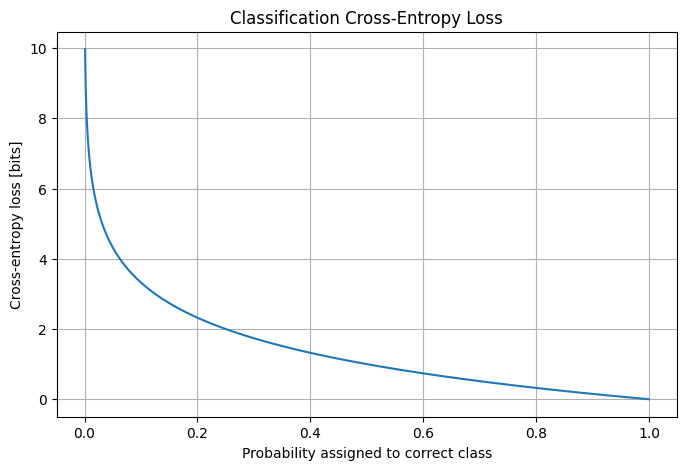

In [64]:
q = np.linspace(0.001, 0.999, 1000)

loss = -np.log2(q)

plt.figure(figsize=(8, 5))

plt.plot(q, loss)

plt.xlabel("Probability assigned to correct class")
plt.ylabel("Cross-entropy loss [bits]")
plt.title("Classification Cross-Entropy Loss")

plt.grid(True)
plt.show()

In [65]:
true_label = np.array([1.0, 0.0, 0.0])

predictions = {
    "Very confident correct": np.array([0.99, 0.005, 0.005]),
    "Moderately confident": np.array([0.70, 0.20, 0.10]),
    "Uncertain": np.array([0.34, 0.33, 0.33]),
    "Confident wrong": np.array([0.01, 0.49, 0.50])
}

for name, q in predictions.items():
    loss = cross_entropy(true_label, q)

    print(
        f"{name:25s}: "
        f"{loss:.4f} bits"
    )

Very confident correct   : 0.0145 bits
Moderately confident     : 0.5146 bits
Uncertain                : 1.5564 bits
Confident wrong          : 6.6439 bits


In [66]:
def softmax(logits):
    """
    Convert logits into probabilities.
    """
    logits = np.asarray(logits, dtype=float)

    # Numerical stability trick
    shifted = logits - np.max(logits)

    exp_values = np.exp(shifted)

    return exp_values / np.sum(exp_values)

logits = np.array([3.0, 1.0, 0.0])

q = softmax(logits)

print("Logits:", logits)
print("Probabilities:", q)
print("Sum:", q.sum())

Logits: [3. 1. 0.]
Probabilities: [0.84379473 0.1141952  0.04201007]
Sum: 1.0


In [67]:
logits = np.array([3.0, 1.0, 0.0])

q = softmax(logits)

true_label = np.array([1.0, 0.0, 0.0])

loss = cross_entropy(true_label, q)

print("Predicted probabilities:", q)
print("Cross-entropy loss:", loss, "bits")

Predicted probabilities: [0.84379473 0.1141952  0.04201007]
Cross-entropy loss: 0.24503601012858323 bits


In [68]:
p = np.array([0.7, 0.2, 0.1])
q = np.array([0.6, 0.3, 0.1])

H_p = entropy(p)
CE = cross_entropy(p, q)

difference = CE - H_p

print("Entropy H(P):", H_p)
print("Cross-entropy H(P,Q):", CE)
print("Difference:", difference)

Entropy H(P): 1.1567796494470395
Cross-entropy H(P,Q): 1.1954618442383218
Difference: 0.03868219479128232


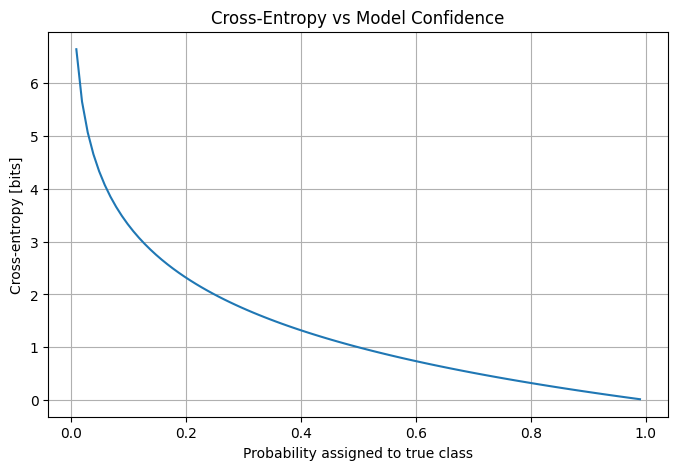

In [69]:
p = np.array([1.0, 0.0])

correct_class_probs = np.linspace(0.01, 0.99, 100)

losses = []

for q_correct in correct_class_probs:
    q = np.array([
        q_correct,
        1 - q_correct
    ])

    losses.append(cross_entropy(p, q))

plt.figure(figsize=(8, 5))

plt.plot(correct_class_probs, losses)

plt.xlabel("Probability assigned to true class")
plt.ylabel("Cross-entropy [bits]")
plt.title("Cross-Entropy vs Model Confidence")

plt.grid(True)
plt.show()

### Part 7 — KL Divergence

In [70]:
def kl_divergence(p, q, eps=1e-12):
    """
    Compute KL divergence D_KL(P || Q) in bits.

    D_KL(P || Q) = sum P(x) log2(P(x) / Q(x))
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if not np.isclose(p.sum(), 1.0):
        raise ValueError("P must sum to 1.")

    if not np.isclose(q.sum(), 1.0):
        raise ValueError("Q must sum to 1.")

    p_safe = np.clip(p, eps, 1.0)
    q_safe = np.clip(q, eps, 1.0)

    return np.sum(
        p_safe * np.log2(p_safe / q_safe)
    )

In [71]:
p = np.array([0.7, 0.2, 0.1])

print("KL(P || P):", kl_divergence(p, p))

KL(P || P): 0.0


In [72]:
p = np.array([0.7, 0.2, 0.1])
q = np.array([0.6, 0.3, 0.1])

print("KL(P || Q):", kl_divergence(p, q))

KL(P || Q): 0.03868219479128239


In [73]:
H_P = entropy(p)
H_PQ = cross_entropy(p, q)

kl_direct = kl_divergence(p, q)
kl_from_cross_entropy = H_PQ - H_P

print("KL directly:", kl_direct)
print("KL from CE - entropy:", kl_from_cross_entropy)

KL directly: 0.03868219479128239
KL from CE - entropy: 0.03868219479128232


In [74]:
p = np.array([0.7, 0.2, 0.1])

predictions = {
    "Perfect": np.array([0.7, 0.2, 0.1]),
    "Very close": np.array([0.65, 0.25, 0.10]),
    "Moderately wrong": np.array([0.50, 0.30, 0.20]),
    "Very wrong": np.array([0.10, 0.20, 0.70])
}

for name, q in predictions.items():
    print(
        f"{name:20s}: "
        f"KL = {kl_divergence(p, q):.4f} bits"
    )

Perfect             : KL = 0.0000 bits
Very close          : KL = 0.0105 bits
Moderately wrong    : KL = 0.1228 bits
Very wrong          : KL = 1.6844 bits


In [75]:
rng = np.random.default_rng(42)

for _ in range(5):

    p = rng.random(4)
    p = p / p.sum()

    q = rng.random(4)
    q = q / q.sum()

    kl = kl_divergence(p, q)

    print(f"KL = {kl:.6f}")

KL = 0.595799
KL = 0.771127
KL = 0.078691
KL = 1.424692
KL = 0.477689


In [77]:
p = np.array([0.8, 0.15, 0.05])
q = np.array([0.5, 0.3, 0.2])

kl_pq = kl_divergence(p, q)
kl_qp = kl_divergence(q, p)

print("KL(P || Q):", kl_pq)
print("KL(Q || P):", kl_qp)

p = np.array([0.9, 0.1])
q = np.array([0.5, 0.5])

print("D_KL(P || Q):", kl_divergence(p, q))
print("D_KL(Q || P):", kl_divergence(q, p))

KL(P || Q): 0.29245752409011017
KL(Q || P): 0.36096404744368116
D_KL(P || Q): 0.5310044064107189
D_KL(Q || P): 0.7369655941662061


In [78]:
p = np.array([0.5, 0.5])
q = np.array([1.0, 0.0])

print("KL(P || Q):", kl_divergence(p, q))

KL(P || Q): 18.931568569324174


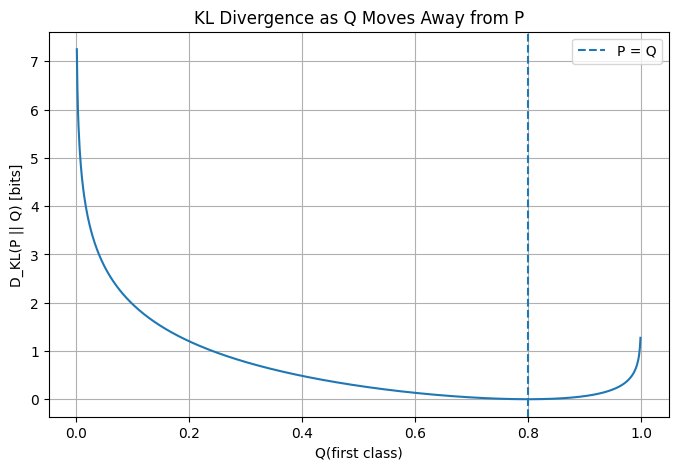

In [80]:
p = np.array([0.8, 0.2])

q_values = np.linspace(0.001, 0.999, 1000)

kl_values = []

for q1 in q_values:
    q = np.array([q1, 1 - q1])

    kl_values.append(
        kl_divergence(p, q)
    )

plt.figure(figsize=(8, 5))

plt.plot(q_values, kl_values)

plt.axvline(0.8, linestyle="--", label="P = Q")

plt.xlabel("Q(first class)")
plt.ylabel("D_KL(P || Q) [bits]")
plt.title("KL Divergence as Q Moves Away from P")

plt.legend()
plt.grid(True)
plt.show()

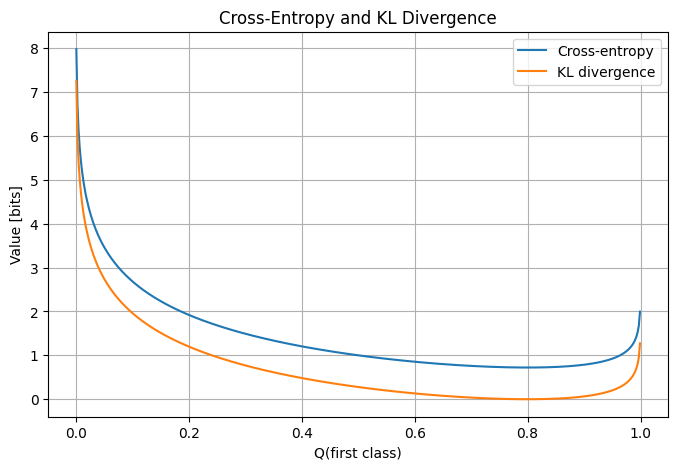

In [82]:
p = np.array([0.8, 0.2])

q_values = np.linspace(0.001, 0.999, 500)

ce_values = []
kl_values = []

for q1 in q_values:

    q = np.array([q1, 1 - q1])

    ce_values.append(cross_entropy(p, q))
    kl_values.append(kl_divergence(p, q))

plt.figure(figsize=(8, 5))

plt.plot(q_values, ce_values, label="Cross-entropy")
plt.plot(q_values, kl_values, label="KL divergence")

plt.xlabel("Q(first class)")
plt.ylabel("Value [bits]")
plt.title("Cross-Entropy and KL Divergence")

plt.legend()
plt.grid(True)
plt.show()

In [83]:
rng = np.random.default_rng(123)

for _ in range(100):

    p = rng.random(5)
    p /= p.sum()

    q = rng.random(5)
    q /= q.sum()

    # KL must be non-negative
    assert kl_divergence(p, q) >= -1e-10

    # KL(P || P) must be zero
    assert np.isclose(
        kl_divergence(p, p),
        0.0
    )

print("All KL tests passed!")

All KL tests passed!


### Part 7 — KL Divergence Between Gaussian Distributions

In [84]:
def gaussian_pdf(x, mean=0.0, std=1.0):
    """
    Probability density function of a 1D Gaussian.
    """
    x = np.asarray(x, dtype=float)

    variance = std ** 2

    coefficient = 1 / np.sqrt(2 * np.pi * variance)

    exponent = -((x - mean) ** 2) / (2 * variance)

    return coefficient * np.exp(exponent)

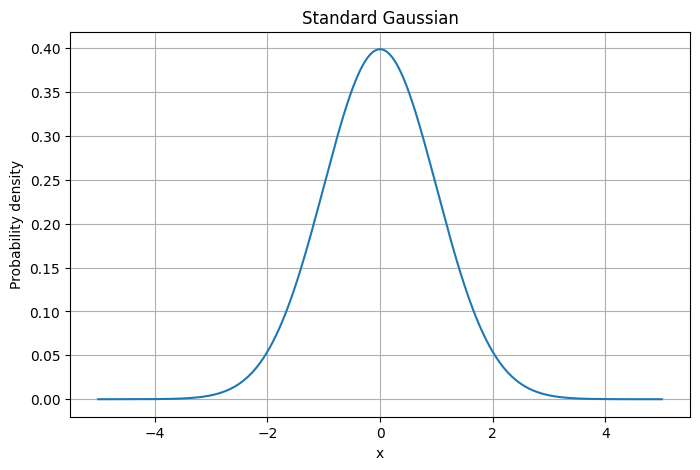

In [85]:
x = np.linspace(-5, 5, 1000)

p = gaussian_pdf(x, mean=0, std=1)

plt.figure(figsize=(8, 5))

plt.plot(x, p)

plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Standard Gaussian")

plt.grid(True)
plt.show()

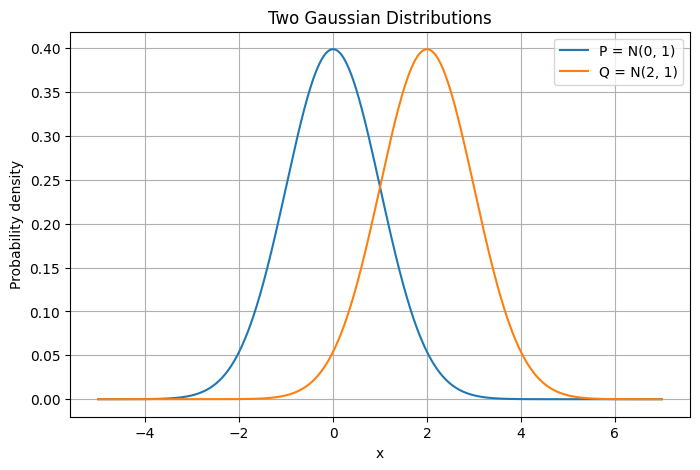

In [86]:
x = np.linspace(-5, 7, 1000)

p = gaussian_pdf(x, mean=0, std=1)
q = gaussian_pdf(x, mean=2, std=1)

plt.figure(figsize=(8, 5))

plt.plot(x, p, label="P = N(0, 1)")
plt.plot(x, q, label="Q = N(2, 1)")

plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Two Gaussian Distributions")

plt.legend()
plt.grid(True)
plt.show()

In [87]:
def gaussian_kl_divergence(
    mean_p,
    std_p,
    mean_q,
    std_q,
    x_min=-10,
    x_max=10,
    num_points=100_000
):
    """
    Numerically approximate D_KL(P || Q)
    between two 1D Gaussian distributions.

    Result is in bits.
    """

    x = np.linspace(x_min, x_max, num_points)

    p = gaussian_pdf(x, mean_p, std_p)
    q = gaussian_pdf(x, mean_q, std_q)

    eps = 1e-12

    p_safe = np.clip(p, eps, None)
    q_safe = np.clip(q, eps, None)

    integrand = p * np.log2(p_safe / q_safe)

    return np.trapezoid(integrand, x)

In [89]:
kl = gaussian_kl_divergence(
    mean_p=0,
    std_p=1,
    mean_q=0,
    std_q=1
)

print("KL(P || Q):", kl, "bits")

kl = gaussian_kl_divergence(
    mean_p=0,
    std_p=1,
    mean_q=2,
    std_q=1
)

print("KL(P || Q):", kl, "bits")

KL(P || Q): 0.0 bits
KL(P || Q): 2.8853899766613984 bits


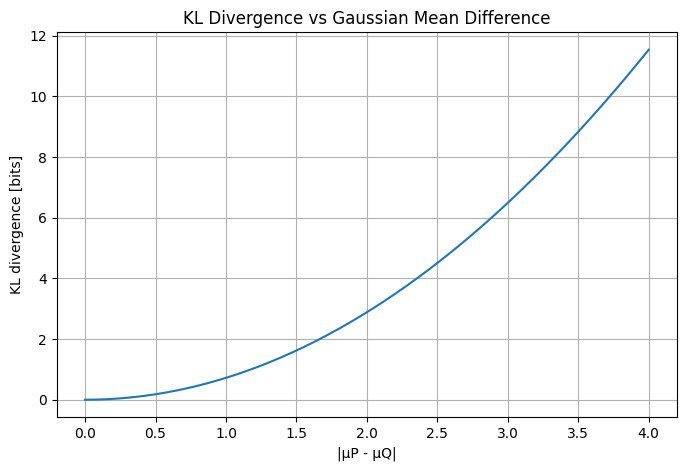

In [90]:
mean_differences = np.linspace(0, 4, 50)

kl_values = []

for difference in mean_differences:

    kl = gaussian_kl_divergence(
        mean_p=0,
        std_p=1,
        mean_q=difference,
        std_q=1
    )

    kl_values.append(kl)

plt.figure(figsize=(8, 5))

plt.plot(mean_differences, kl_values)

plt.xlabel("|μP - μQ|")
plt.ylabel("KL divergence [bits]")
plt.title("KL Divergence vs Gaussian Mean Difference")

plt.grid(True)
plt.show()

KL(P || Q): 0.4589893596670197 bits


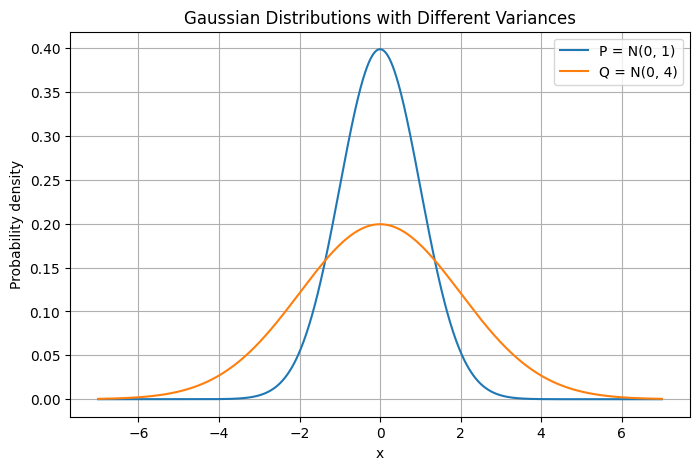

In [91]:
kl = gaussian_kl_divergence(
    mean_p=0,
    std_p=1,
    mean_q=0,
    std_q=2
)

print("KL(P || Q):", kl, "bits")

x = np.linspace(-7, 7, 1000)

p = gaussian_pdf(x, mean=0, std=1)
q = gaussian_pdf(x, mean=0, std=2)

plt.figure(figsize=(8, 5))

plt.plot(x, p, label="P = N(0, 1)")
plt.plot(x, q, label="Q = N(0, 4)")

plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Gaussian Distributions with Different Variances")

plt.legend()
plt.grid(True)
plt.show()

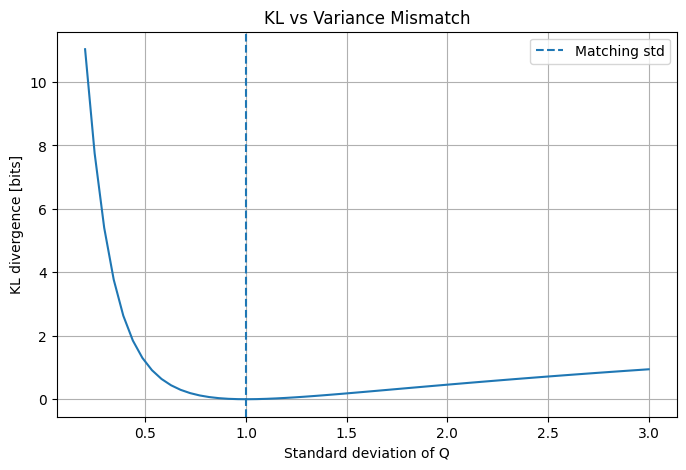

In [92]:
std_values = np.linspace(0.2, 3, 60)

kl_values = []

for std_q in std_values:

    kl = gaussian_kl_divergence(
        mean_p=0,
        std_p=1,
        mean_q=0,
        std_q=std_q
    )

    kl_values.append(kl)

plt.figure(figsize=(8, 5))

plt.plot(std_values, kl_values)

plt.axvline(1, linestyle="--", label="Matching std")

plt.xlabel("Standard deviation of Q")
plt.ylabel("KL divergence [bits]")
plt.title("KL vs Variance Mismatch")

plt.legend()
plt.grid(True)
plt.show()

In [93]:
gaussians = {
    "Same": (0, 1),
    "Shifted mean": (1, 1),
    "Different variance": (0, 2),
    "Mean + variance": (2, 2)
}

for name, (mean_q, std_q) in gaussians.items():

    kl = gaussian_kl_divergence(
        mean_p=0,
        std_p=1,
        mean_q=mean_q,
        std_q=std_q
    )

    print(f"{name:20s}: KL = {kl:.4f} bits")

Same                : KL = 0.0000 bits
Shifted mean        : KL = 0.7213 bits
Different variance  : KL = 0.4590 bits
Mean + variance     : KL = 1.1803 bits


In [94]:
def gaussian_kl_closed_form(
    mean_p,
    std_p,
    mean_q,
    std_q
):
    """
    Exact KL divergence between two 1D Gaussians.

    Result is in bits.
    """

    variance_p = std_p ** 2
    variance_q = std_q ** 2

    kl_nats = (
        np.log(std_q / std_p)
        + (
            variance_p
            + (mean_p - mean_q) ** 2
        ) / (2 * variance_q)
        - 0.5
    )

    return kl_nats / np.log(2)

In [95]:
mean_p = 0
std_p = 1

mean_q = 2
std_q = 1.5

kl_numeric = gaussian_kl_divergence(
    mean_p,
    std_p,
    mean_q,
    std_q
)

kl_exact = gaussian_kl_closed_form(
    mean_p,
    std_p,
    mean_q,
    std_q
)

print("Numerical KL:", kl_numeric)
print("Exact KL:    ", kl_exact)

Numerical KL: 1.466609470153682
Exact KL:     1.4666094701533006


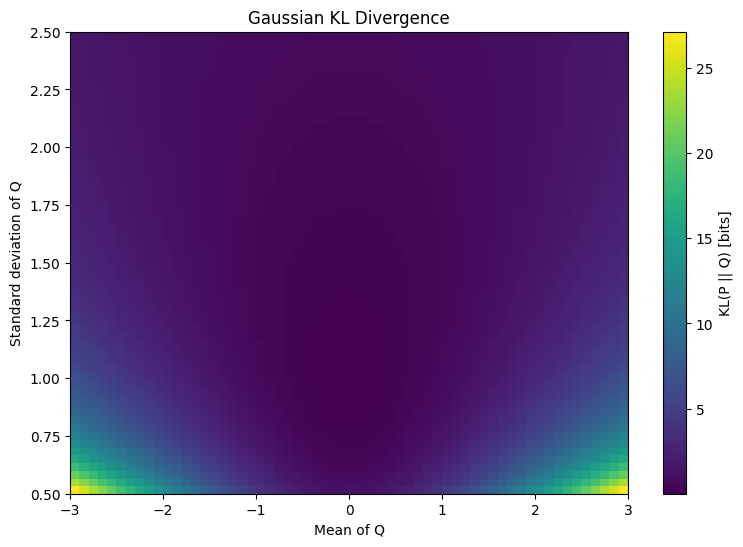

In [97]:
mean_values = np.linspace(-3, 3, 60)
std_values = np.linspace(0.5, 2.5, 60)

KL = np.zeros(
    (len(std_values), len(mean_values))
)

for i, std_q in enumerate(std_values):
    for j, mean_q in enumerate(mean_values):

        KL[i, j] = gaussian_kl_closed_form(
            mean_p=0,
            std_p=1,
            mean_q=mean_q,
            std_q=std_q
        )

plt.figure(figsize=(9, 6))

plt.imshow(
    KL,
    extent=[
        mean_values.min(),
        mean_values.max(),
        std_values.min(),
        std_values.max()
    ],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="KL(P || Q) [bits]")

plt.xlabel("Mean of Q")
plt.ylabel("Standard deviation of Q")
plt.title("Gaussian KL Divergence")

plt.show()

In [98]:
p_to_q = gaussian_kl_closed_form(
    mean_p=0,
    std_p=1,
    mean_q=2,
    std_q=2
)

q_to_p = gaussian_kl_closed_form(
    mean_p=2,
    std_p=2,
    mean_q=0,
    std_q=1
)

print("D_KL(P || Q):", p_to_q)
print("D_KL(Q || P):", q_to_p)

D_KL(P || Q): 1.1803368801111207
D_KL(Q || P): 4.049432643111372


In [99]:
P = (0, 1)

candidates = {
    "Perfect match": (0, 1),
    "Small mean shift": (0.5, 1),
    "Large mean shift": (2, 1),
    "Small variance change": (0, 1.2),
    "Large variance change": (0, 2),
    "Both changed": (2, 2)
}

for name, (mean_q, std_q) in candidates.items():

    kl = gaussian_kl_closed_form(
        P[0],
        P[1],
        mean_q,
        std_q
    )

    print(
        f"{name:25s} "
        f"→ {kl:.4f} bits"
    )

Perfect match             → 0.0000 bits
Small mean shift          → 0.1803 bits
Large mean shift          → 2.8854 bits
Small variance change     → 0.0426 bits
Large variance change     → 0.4590 bits
Both changed              → 1.1803 bits


### Part 8 — Jensen–Shannon Divergence

In [100]:
def mixture_distribution(p, q):
    """
    Compute the midpoint distribution M = (P + Q) / 2.
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if not np.isclose(p.sum(), 1.0):
        raise ValueError("P must sum to 1.")

    if not np.isclose(q.sum(), 1.0):
        raise ValueError("Q must sum to 1.")

    return 0.5 * (p + q)

p = np.array([0.7, 0.2, 0.1])
q = np.array([0.4, 0.4, 0.2])

m = mixture_distribution(p, q)

print("P:", p)
print("Q:", q)
print("M:", m)
print("Sum of M:", m.sum())

P: [0.7 0.2 0.1]
Q: [0.4 0.4 0.2]
M: [0.55 0.3  0.15]
Sum of M: 1.0


In [101]:
def js_divergence(p, q):
    """
    Compute Jensen-Shannon divergence in bits.

    JS(P || Q) =
        0.5 * KL(P || M)
        + 0.5 * KL(Q || M)

    where M = 0.5 * (P + Q).
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    m = mixture_distribution(p, q)

    return (
        0.5 * kl_divergence(p, m)
        + 0.5 * kl_divergence(q, m)
    )

p = np.array([0.7, 0.2, 0.1])
print("JS(P || P):", js_divergence(p, p))

p = np.array([0.7, 0.2, 0.1])
q = np.array([0.4, 0.4, 0.2])

print("KL(P || Q):", kl_divergence(p, q))
print("KL(Q || P):", kl_divergence(q, p))
print("JS(P || Q):", js_divergence(p, q))

JS(P || P): 0.0
KL(P || Q): 0.2651484454403227
KL(Q || P): 0.27705803117695843
JS(P || Q): 0.06665370714512754


In [102]:
js_pq = js_divergence(p, q)
js_qp = js_divergence(q, p)

print("JS(P || Q):", js_pq)
print("JS(Q || P):", js_qp)

assert np.isclose(js_pq, js_qp)

print("JS is symmetric!")

JS(P || Q): 0.06665370714512754
JS(Q || P): 0.06665370714512754
JS is symmetric!


In [103]:
p = np.array([1.0, 0.0])
q = np.array([0.0, 1.0])

print("KL(P || Q):", kl_divergence(p, q))
print("KL(Q || P):", kl_divergence(q, p))

KL(P || Q): 39.86313713860849
KL(Q || P): 39.86313713860849


In [104]:
print("JS(P || Q):", js_divergence(p, q))

JS(P || Q): 0.9999999999611369


In [105]:
rng = np.random.default_rng(42)

js_values = []

for _ in range(1000):

    p = rng.random(5)
    p /= p.sum()

    q = rng.random(5)
    q /= q.sum()

    js = js_divergence(p, q)

    js_values.append(js)

print("Minimum JS:", min(js_values))
print("Maximum JS:", max(js_values))

Minimum JS: 0.002617018526622713
Maximum JS: 0.5415448268497804


In [106]:
p = np.array([0.8, 0.2])

q_values = np.linspace(0.001, 0.999, 500)

js_values = []
kl_values = []

for q1 in q_values:

    q = np.array([
        q1,
        1 - q1
    ])

    js_values.append(
        js_divergence(p, q)
    )

    kl_values.append(
        kl_divergence(p, q)
    )

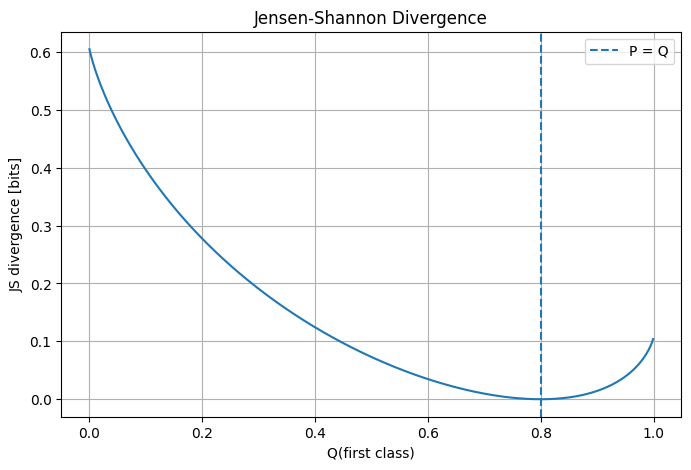

In [107]:
plt.figure(figsize=(8, 5))

plt.plot(q_values, js_values)

plt.axvline(
    0.8,
    linestyle="--",
    label="P = Q"
)

plt.xlabel("Q(first class)")
plt.ylabel("JS divergence [bits]")
plt.title("Jensen-Shannon Divergence")

plt.legend()
plt.grid(True)
plt.show()

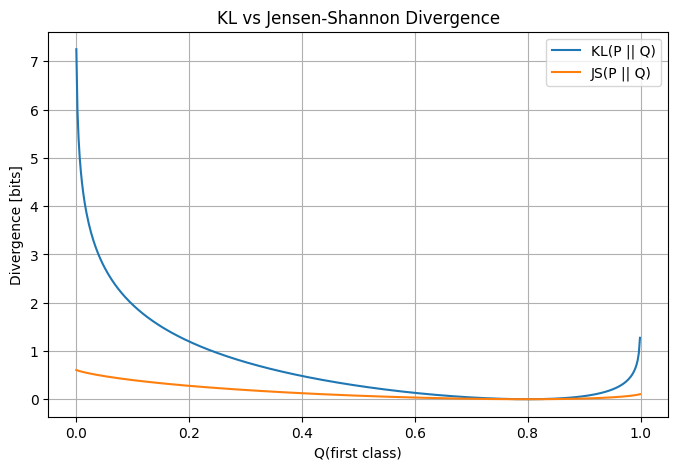

In [108]:
plt.figure(figsize=(8, 5))

plt.plot(
    q_values,
    kl_values,
    label="KL(P || Q)"
)

plt.plot(
    q_values,
    js_values,
    label="JS(P || Q)"
)

plt.xlabel("Q(first class)")
plt.ylabel("Divergence [bits]")
plt.title("KL vs Jensen-Shannon Divergence")

plt.legend()
plt.grid(True)
plt.show()

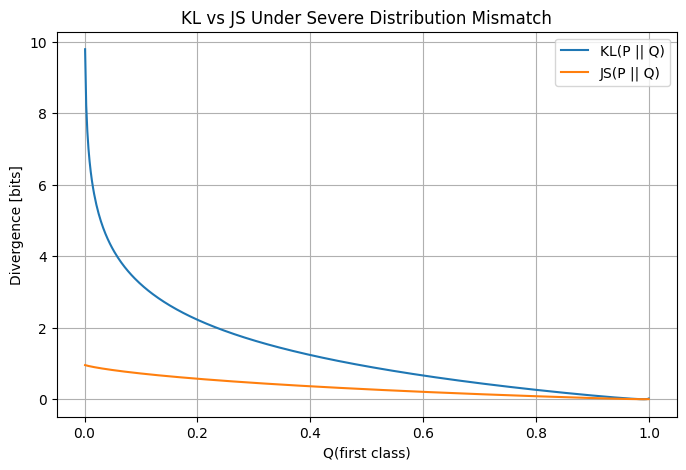

In [109]:
p = np.array([0.99, 0.01])

q_values = np.linspace(0.001, 0.999, 500)

kl_values = []
js_values = []

for q1 in q_values:

    q = np.array([q1, 1 - q1])

    kl_values.append(
        kl_divergence(p, q)
    )

    js_values.append(
        js_divergence(p, q)
    )

plt.figure(figsize=(8, 5))

plt.plot(
    q_values,
    kl_values,
    label="KL(P || Q)"
)

plt.plot(
    q_values,
    js_values,
    label="JS(P || Q)"
)

plt.xlabel("Q(first class)")
plt.ylabel("Divergence [bits]")
plt.title("KL vs JS Under Severe Distribution Mismatch")

plt.legend()
plt.grid(True)
plt.show()

In [110]:
def js_divergence_entropy_form(p, q):
    """
    Jensen-Shannon divergence using entropy.

    JS(P,Q) = H(M) - 0.5 H(P) - 0.5 H(Q)
    """
    m = mixture_distribution(p, q)

    return (
        entropy(m)
        - 0.5 * entropy(p)
        - 0.5 * entropy(q)
    )

p = np.array([0.7, 0.2, 0.1])
q = np.array([0.4, 0.4, 0.2])

js_kl_form = js_divergence(p, q)
js_entropy = js_divergence_entropy_form(p, q)

print("JS using KL:", js_kl_form)
print("JS using entropy:", js_entropy)

assert np.isclose(js_kl_form, js_entropy)

print("Both formulations agree!")

JS using KL: 0.06665370714512754
JS using entropy: 0.06665370714512775
Both formulations agree!


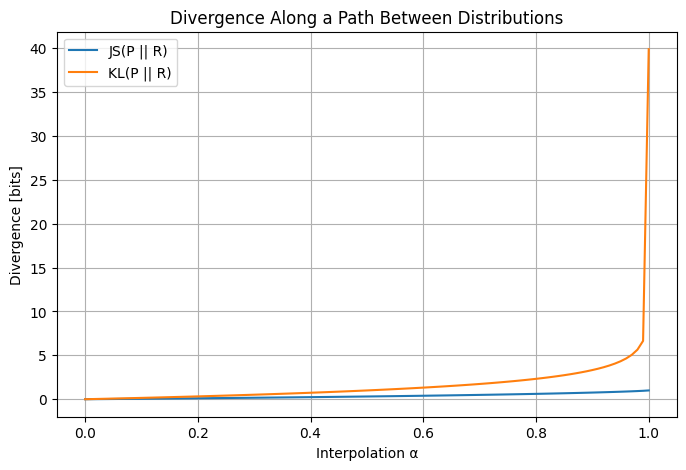

In [112]:
p = np.array([1.0, 0.0])
q = np.array([0.0, 1.0])

alphas = np.linspace(0, 1, 101)

js_values = []
kl_values = []

for alpha in alphas:

    r = (1 - alpha) * p + alpha * q

    js_values.append(
        js_divergence(p, r)
    )

    kl_values.append(
        kl_divergence(p, r)
    )

plt.figure(figsize=(8, 5))

plt.plot(
    alphas,
    js_values,
    label="JS(P || R)"
)

plt.plot(
    alphas,
    kl_values,
    label="KL(P || R)"
)

plt.xlabel("Interpolation α")
plt.ylabel("Divergence [bits]")
plt.title("Divergence Along a Path Between Distributions")

plt.legend()
plt.grid(True)
plt.show()

### Part 9 — Final Integrated Experiment

In [113]:
rng = np.random.default_rng(42)

n = 100_000

Y = rng.integers(0, 2, size=n)

print("Number of samples:", n)
print("P(Y=0):", np.mean(Y == 0))
print("P(Y=1):", np.mean(Y == 1))

Number of samples: 100000
P(Y=0): 0.49911
P(Y=1): 0.50089


In [114]:
p_y = np.array([
    np.mean(Y == 0),
    np.mean(Y == 1)
])

H_Y = entropy(p_y)

print("P(Y):", p_y)
print("H(Y):", H_Y, "bits")

P(Y): [0.49911 0.50089]
H(Y): 0.9999977144813094 bits


In [115]:
noise_probability = 0.10

noise = rng.random(n) < noise_probability

X1 = np.logical_xor(
    Y,
    noise
).astype(int)

print("First 20 Y:")
print(Y[:20])

print("\nFirst 20 X1:")
print(X1[:20])

First 20 Y:
[0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0]

First 20 X1:
[0 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0]


In [116]:
X2 = rng.integers(0, 2, size=n)

print("First 20 X2:")
print(X2[:20])

First 20 X2:
[0 1 1 1 1 1 0 1 1 1 0 0 1 0 0 0 1 0 1 0]


In [117]:
joint_x1_y = empirical_joint_distribution(X1, Y)
joint_x2_y = empirical_joint_distribution(X2, Y)

mi_x1_y = mutual_information(joint_x1_y)
mi_x2_y = mutual_information(joint_x2_y)

print("I(X1;Y):", mi_x1_y, "bits")
print("I(X2;Y):", mi_x2_y, "bits")

I(X1;Y): 0.5338449072169427 bits
I(X2;Y): 3.550340066382773e-08 bits


In [118]:
H_Y_given_X1 = conditional_entropy(joint_x1_y)
H_Y_given_X2 = conditional_entropy(joint_x2_y)

print("H(Y):", H_Y)
print("H(Y | X1):", H_Y_given_X1)
print("H(Y | X2):", H_Y_given_X2)

H(Y): 0.9999977144813094
H(Y | X1): 0.4661528072643668
H(Y | X2): 0.9999976789779086


In [119]:
predicted_probabilities = np.where(
    X1 == 1,
    0.90,
    0.10
)

print(predicted_probabilities[:20])

[0.1 0.9 0.9 0.1 0.1 0.9 0.1 0.9 0.1 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.1
 0.9 0.1]


In [120]:
true_class_probabilities = np.where(
    Y == 1,
    predicted_probabilities,
    1 - predicted_probabilities
)

individual_losses = -np.log2(
    np.clip(true_class_probabilities, 1e-12, 1.0)
)

average_cross_entropy = np.mean(
    individual_losses
)

print(
    "Average cross-entropy:",
    average_cross_entropy,
    "bits"
)

Average cross-entropy: 0.4661743603379974 bits


In [121]:
bad_predicted_probabilities = np.where(
    X1 == 1,
    0.60,
    0.40
)

bad_true_class_probabilities = np.where(
    Y == 1,
    bad_predicted_probabilities,
    1 - bad_predicted_probabilities
)

bad_losses = -np.log2(
    np.clip(
        bad_true_class_probabilities,
        1e-12,
        1.0
    )
)

bad_cross_entropy = np.mean(bad_losses)

print(
    "Good model CE:",
    average_cross_entropy
)

print(
    "Bad model CE:",
    bad_cross_entropy
)

Good model CE: 0.4661743603379974
Bad model CE: 0.7949412276126798


In [122]:
overconfident_probs = np.where(
    X1 == 1,
    0.999,
    0.001
)

overconfident_true_probs = np.where(
    Y == 1,
    overconfident_probs,
    1 - overconfident_probs
)

overconfident_losses = -np.log2(
    np.clip(
        overconfident_true_probs,
        1e-12,
        1.0
    )
)

overconfident_ce = np.mean(
    overconfident_losses
)

print(
    "Overconfident model CE:",
    overconfident_ce,
    "bits"
)

Overconfident model CE: 0.9890092402765756 bits


In [123]:
print(
    f"Good model:          {average_cross_entropy:.4f} bits"
)

print(
    f"Bad model:           {bad_cross_entropy:.4f} bits"
)

print(
    f"Overconfident model: {overconfident_ce:.4f} bits"
)

Good model:          0.4662 bits
Bad model:           0.7949 bits
Overconfident model: 0.9890 bits


In [124]:
p_true = np.array([0.1, 0.9])

q_good = np.array([0.1, 0.9])
q_bad = np.array([0.4, 0.6])

print(
    "KL(true || good):",
    kl_divergence(p_true, q_good)
)

print(
    "KL(true || bad):",
    kl_divergence(p_true, q_bad)
)

KL(true || good): 0.0
KL(true || bad): 0.3264662506490406


In [125]:
print(
    "JS(true, good):",
    js_divergence(p_true, q_good)
)

print(
    "JS(true, bad):",
    js_divergence(p_true, q_bad)
)

JS(true, good): 0.0
JS(true, bad): 0.0913050304371579


In [126]:
models = {
    "Perfect": np.array([0.1, 0.9]),
    "Good": np.array([0.2, 0.8]),
    "Uncertain": np.array([0.5, 0.5]),
    "Bad": np.array([0.7, 0.3]),
    "Very wrong": np.array([0.95, 0.05])
}

print(
    f"{'Model':<15}"
    f"{'CE':>12}"
    f"{'KL':>12}"
    f"{'JS':>12}"
)

print("-" * 51)

for name, q in models.items():

    ce = cross_entropy(p_true, q)
    kl = kl_divergence(p_true, q)
    js = js_divergence(p_true, q)

    print(
        f"{name:<15}"
        f"{ce:>12.4f}"
        f"{kl:>12.4f}"
        f"{js:>12.4f}"
    )

Model                    CE          KL          JS
---------------------------------------------------
Perfect              0.4690      0.0000      0.0000
Good                 0.5219      0.0529      0.0144
Uncertain            1.0000      0.5310      0.1468
Bad                  1.6147      1.1457      0.2958
Very wrong           3.8971      3.4281      0.6205


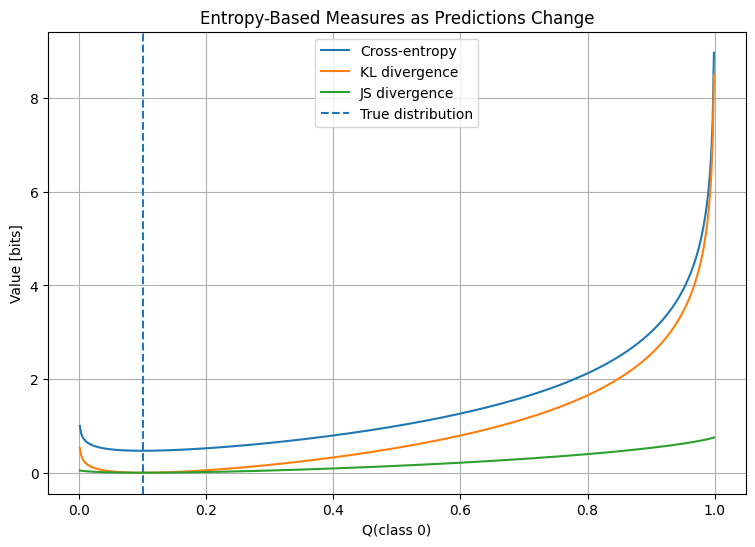

In [127]:
p = np.array([0.1, 0.9])

q_values = np.linspace(0.001, 0.999, 500)

ce_values = []
kl_values = []
js_values = []

for q1 in q_values:

    q = np.array([
        q1,
        1 - q1
    ])

    ce_values.append(
        cross_entropy(p, q)
    )

    kl_values.append(
        kl_divergence(p, q)
    )

    js_values.append(
        js_divergence(p, q)
    )

plt.figure(figsize=(9, 6))

plt.plot(
    q_values,
    ce_values,
    label="Cross-entropy"
)

plt.plot(
    q_values,
    kl_values,
    label="KL divergence"
)

plt.plot(
    q_values,
    js_values,
    label="JS divergence"
)

plt.axvline(
    0.1,
    linestyle="--",
    label="True distribution"
)

plt.xlabel("Q(class 0)")
plt.ylabel("Value [bits]")
plt.title("Entropy-Based Measures as Predictions Change")

plt.legend()
plt.grid(True)
plt.show()